# Evaluation of Regression Model

This model was attempting to predict the total reward for a lunar lander game based on the recording of the video. The data was split 70/15/15 into train/validation/test. During training early stopping was used based on validation loss. Then we looked at how the model performed on the held out test set.

In [ ]:
import json
from typing import cast
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import DataLoader, Subset

from network.dataclass import LunarLanderDataset
from network.model import LunarLanderConv

### Looking at the train/validation loss history

In [4]:
OUTPUT_PATH = Path("..") / "output" / "20260525_162221"

In [5]:
with open (OUTPUT_PATH / "history.json", "r") as f:
    history = json.load(f)

In [15]:
train_epochs =[a[0] for a in history["train_history"]]
train_loss = [a[1] for a in history["train_history"]]
val_history = [a[1] for a in history["val_history"]]
val_epochs = [a[0] for a in history["val_history"]]

In [19]:
train_hist = pd.DataFrame({"epoch": train_epochs, "loss": train_loss})
val_hist = pd.DataFrame({"epoch": val_epochs, "val_loss": val_history})

In [22]:
loss_df = train_hist.merge(val_hist, on = "epoch")


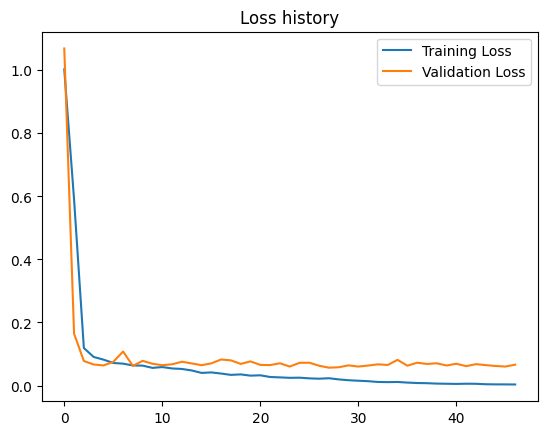

In [ ]:
loss_df.loss.plot()
loss_df.val_loss.plot()
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss history")

plt.show()

### Evaluation of the model on the held out test data.

We load the test data and pass it through the model and record the results. Note that `data/preprocessed.h5` is not in the repository. To generate it, use the `process_videos.py` script.

In [33]:
state_dict = torch.load(OUTPUT_PATH / "best_model.pt")
model = LunarLanderConv()
model.load_state_dict(state_dict)
scaler = joblib.load(OUTPUT_PATH / "reward_scaler.pkl")
dataset = LunarLanderDataset("../data/preprocessed.h5")
test_indices = torch.load(OUTPUT_PATH / "test_indices.pt")
test_ds = Subset(dataset, test_indices)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False)

In [35]:
model.eval()
all_preds = []
all_actuals = []
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
with torch.no_grad():
    for batch in test_loader:
        frames: torch.Tensor
        lengths: torch.Tensor
        rewards: torch.Tensor
        frames, lengths, rewards = batch
        frames = frames.to(device)
        lengths = lengths.to(device)
        out = cast(torch.Tensor, model(frames, lengths))
        all_preds.append(out.squeeze().cpu().numpy())
        all_actuals.append(rewards.cpu().numpy())

preds = np.concatenate(all_preds).reshape(-1, 1)
actuals = np.concatenate(all_actuals).reshape(-1, 1)

preds_unscaled = scaler.inverse_transform(preds)
# actuals are already in original scale from the dataset

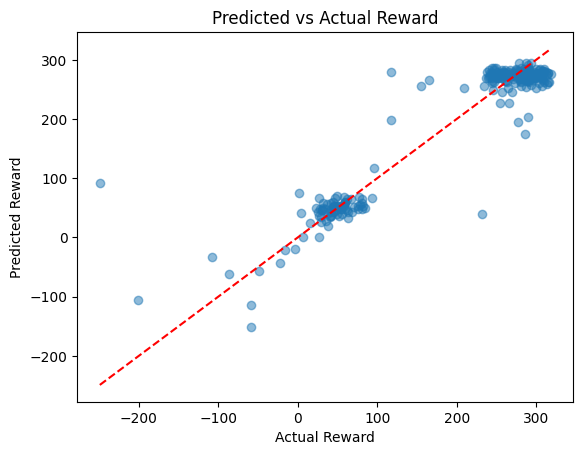

In [36]:
plt.scatter(actuals, preds_unscaled, alpha=0.5)
plt.xlabel("Actual Reward")
plt.ylabel("Predicted Reward")
plt.title("Predicted vs Actual Reward")
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--')  # perfect prediction line
plt.show()

In [ ]:


mse = mean_squared_error(actuals, preds_unscaled)
mae = mean_absolute_error(actuals, preds_unscaled)
print(f"MSE: {mse:.2f}, RMSE: {mse**0.5:.2f}, MAE: {mae:.2f}")

MSE: 1424.88, RMSE: 37.75, MAE: 22.96
